# A tutorial walkthrough of CYCLOPS

This notebook builds CYCLOPS (Cyclostationary Profiling via Coprime Sampling)
in stages, using small signals that can be inspected directly, rather than
running the full experiment suite. The numbers reported in the paper are
produced instead by `reproduce_paper.ipynb`; the purpose here is to
illustrate how the method operates.

A digitally modulated signal contains a hidden, exactly periodic component
at its symbol rate, obscured by what otherwise resembles random noise. The
task addressed below is locating that hidden rate's exact frequency among
$N$ possible candidates at low cost. Rather than testing all $N$ candidates
directly, at cost $O(N\log N)$, the method divides the test into two
smaller, independent tests of sizes $M_1$ and $M_2$, coprime with
$M_1 M_2 = N$, and recombines the two partial results into a single exact
answer using the Chinese Remainder Theorem, at cost $O(\sqrt N\log N)$.

The next cell states the problem formally, following Section II of the
paper. The method is then developed in six stages, each accompanied by a
runnable example: the delay product, by which a hidden periodic rate
becomes observable; exact decimation folding, in which only $M$ of $N$
possible positions are examined; the CRT, which yields one exact answer
that arrives together with several candidates; recombination and
verification, by which the true answer is selected among them;
harmonic-order resolution, needed when the strongest peak is not the
fundamental; and profile readout, in which the full harmonic comb is
obtained once the rate is known. A final section calls the estimator end to
end.

Every code cell below calls the functions actually used in this codebase
(`coprime.py`, `fold_core.py`, `twostage.py`) on small, easily inspected
examples; none of the code here is a simplified reimplementation.

## Problem formulation

This mirrors Section II of the paper, and the symbols below are the ones
used throughout both.

Let $x(t)$, $t=0,\dots,N-1$, be a complex baseband window containing a
linearly modulated signal of symbol (or chip) rate $\alpha_0$, together
with additive noise. The quantity exposing the hidden rate is the
non-conjugate cyclic autocorrelation, estimated at cycle frequency $\alpha$
and lag $\tau$ over a sample set $\mathcal{S}$,

$$\widehat{R}_x^{\alpha}(\tau) = \frac{1}{|\mathcal{S}|}
   \sum_{t\in\mathcal{S}} x(t+\tau)\,x^{*}(t)\, e^{-i2\pi\alpha t}.$$

Equivalently, the delay product $x(t+\tau)x^{*}(t)$, treated in Stage 1
below, is formed and its energy at frequency $\alpha$ measured. This
quantity is nonzero at $\alpha=m\alpha_0$ for integer $m$, the fundamental
and its harmonics. The set $\mathcal{S}$ need not comprise every sample;
choosing it as a decimated subset is exactly what Stage 2 exploits.

A single lag is noisy, so $L$ of them are combined into a working statistic

$$T(\alpha) = \Big(\textstyle\sum_{\tau\in\mathcal{L}}
            \big|\widehat{R}_x^{\alpha}(\tau)\big|^2\Big)^{1/2},
\qquad \mathcal{L}=\{\tau_1,\dots,\tau_L\},$$

implemented as `fine_statistic` in the code. Which lags belong to
$\mathcal{L}$ is not arbitrary, and is addressed under "Choosing the lag
set" following Stage 2.

A length-$N$ window has native bins at $\alpha=q/N$ for $q=0,\dots,N-1$.
The goal is to locate $q_0=\mathrm{round}(\alpha_0 N)$, the native bin of
the fundamental, and to report the alpha-profile
$P(m\alpha_0)\triangleq T(m\alpha_0)$ at each of $H$ harmonics,
$m=1,\dots,H$. Locating $q_0$ amounts to estimating $\alpha_0$ to within
one bin, which is why every experiment scores a trial correct when
$|\hat\alpha_0-\alpha_0|<1/(2N)$. A length-$N$ transform performs this at
cost $O(N\log N)$; the remainder of this notebook obtains the same $q_0$
at cost $O(\sqrt N\log N)$.

The rounding in $q_0$ assumes $\alpha_0 N$ is close to an integer. When the
symbol clock is unrelated to the record length this need not hold, and the
estimate degrades; this case is measured in Section IV-F of the paper.

N=4032 = 63 x 64  (coprime: gcd=1)
true fundamental: alpha0 = 1/24 = 0.04167, native bin q0 = 168
residues we're hoping to recover: q0 mod M1 = 42, q0 mod M2 = 40


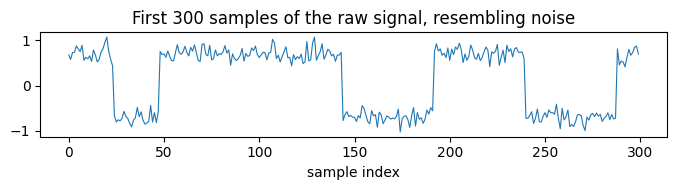

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

from twostage import make_signal_exact_N, fine_statistic, peak_candidates
from fold_core import fine_fft
from coprime import crt_combine, peak_candidates_with_dc, verify_candidate, coprime_alpha0, resolve_harmonic_order, local_floor
from test_dsss import make_dsss_signal

# Running toy example for stages 1 through 5: a small QPSK signal.
# N = M1 * M2 with M1, M2 coprime, following the paper's recommendation
# of consecutive integers (63, 64), small enough to plot and inspect,
# and large enough to behave like the real thing.
N, M1, M2 = 4032, 63, 64
D1, D2 = N // M1, N // M2   # strides for each branch
K = 24                       # symbol period in samples = 1/alpha0
q0_true = N // K            # the exact bin we're trying to find
lags = [4, 8, 12, 16, 20, 24] # delay-product lags, same set used throughout the codebase

print(f"N={N} = {M1} x {M2}  (coprime: gcd={np.gcd(M1,M2)})")
print(f"true fundamental: alpha0 = 1/{K} = {1/K:.5f}, native bin q0 = {q0_true}")
print(f"residues we're hoping to recover: q0 mod M1 = {q0_true % M1}, q0 mod M2 = {q0_true % M2}")

rng = np.random.default_rng(42)
x = make_signal_exact_N("QPSK", "rect", K, N, 15.0, rng)

fig, ax = plt.subplots(figsize=(7, 2))
ax.plot(np.real(x[:300]), lw=0.8)
ax.set_title("First 300 samples of the raw signal, resembling noise")
ax.set_xlabel("sample index")
plt.tight_layout()
plt.show()

## Stage 1: The delay product

The raw signal shown above does not visibly repeat, since the symbols are
random and no obvious rhythm is apparent. The timing, however, is not
random: symbols change at a fixed rate. This hidden rate is exposed by the
delay product, formed by multiplying the signal by a delayed, conjugated
copy of itself,

$$z_\tau(t) = x(t+\tau)\,x^*(t).$$

For a plain sinusoid this quantity is constant and carries no rate
information. For a genuine symbol stream it removes most of the random
symbol content and leaves a residual that is exactly periodic at the
symbol rate. Below, $z_\tau(t)$ is computed over the entire window and
passed through one full-length FFT, the expensive $O(N\log N)$ reference
that the following stages avoid.

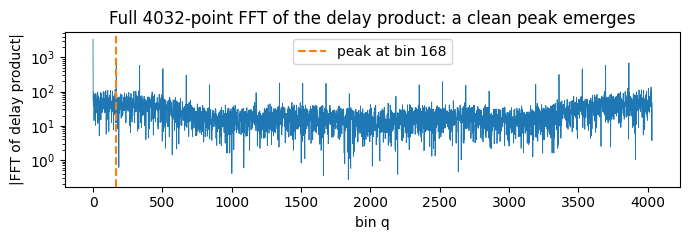

located bin: 168, true bin: 168, match: True
this cost one 4032-point FFT, which the following stages avoid computing directly


In [2]:
tau = 4  # one lag; the real estimator combines several, see fine_statistic below
z_full = x[tau:tau+N] * np.conj(x[0:N])
X_full = np.fft.fft(z_full)
mag = np.abs(X_full)
peak_bin = np.argmax(mag[1:]) + 1  # bin 0 is the always-present non-cyclic term, not a cyclic feature, and is skipped

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(mag, lw=0.6)
ax.axvline(peak_bin, color="C1", ls="--", label=f"peak at bin {peak_bin}")
ax.set_yscale("log")
ax.set_xlabel("bin q")
ax.set_ylabel("|FFT of delay product|")
ax.set_title(f"Full {N}-point FFT of the delay product: a clean peak emerges")
ax.legend()
plt.tight_layout()
plt.show()

print(f"located bin: {peak_bin}, true bin: {q0_true}, match: {peak_bin == q0_true}")
print(f"this cost one {N}-point FFT, which the following stages avoid computing directly")

## Stage 2: Exact decimation folding

The full $N$-point FFT is the expensive step. The identity underlying this
method states that keeping every $D$-th sample of the delay product, at
stride $D=N/M$, and taking an $M$-point FFT of those samples alone, gives
exactly the $N$-point spectrum folded onto $M$ bins: bin $p$ holds the sum
of every native bin $q$ with $q \bmod M = p$, without approximation.

The dense $z_\tau(t)$ of Stage 1 is not formed in this construction, since
computing it at all $N$ positions would itself cost $O(N)$, reintroducing
the cost the construction is meant to avoid. `fine_fft` evaluates
$z_\tau$ only at the stride positions each branch requires.

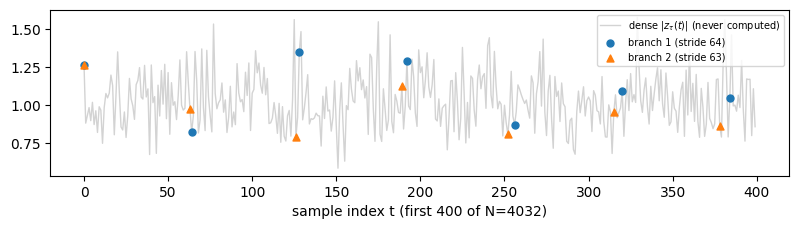

dense: 4032 evaluations.  decimated: 63+64=127 (126 distinct positions), leaving 96.9% of the record untouched


In [3]:
idx1 = D1 * np.arange(M1)   # the only positions branch 1 examines
idx2 = D2 * np.arange(M2)

zoom = 400
fig, ax = plt.subplots(figsize=(8, 2.4))
ax.plot(np.abs(z_full[:zoom]), color="lightgray", lw=1, label=r"dense $|z_\tau(t)|$ (never computed)")
m1 = idx1[idx1 < zoom]; m2 = idx2[idx2 < zoom]
ax.scatter(m1, np.abs(z_full[m1]), color="C0", s=25, zorder=3, label=f"branch 1 (stride {D1})")
ax.scatter(m2, np.abs(z_full[m2]), color="C1", s=25, zorder=3, marker="^", label=f"branch 2 (stride {D2})")
ax.set_xlabel(f"sample index t (first {zoom} of N={N})")
ax.legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

touched = len(set(idx1) | set(idx2))
print(f"dense: {N} evaluations.  decimated: {M1}+{M2}={M1+M2} "
      f"({touched} distinct positions), leaving {100*(N-touched)/N:.1f}% of the record untouched")

### The catch: each residue matches many native bins

A branch reports $q \bmod M$, not $q$. Every native bin sharing that
residue folds onto the same small-FFT bin, so a single branch leaves $N/M$
candidates that it cannot distinguish, even in principle. This ambiguity
is made explicit below for the toy signal.

branch 1 says q = 42 (mod 63) -> 64 possible native bins: 42, 105, 168, 231, 294, ...
branch 2 says q = 40 (mod 64) -> 63 possible native bins: 40, 104, 168, 232, 296, ...

bins consistent with BOTH branches: [168]   (true q0 = 168)


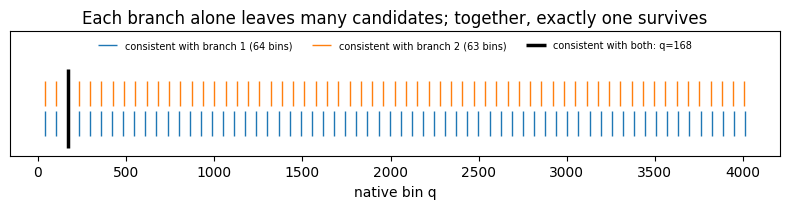

In [4]:
T1 = fine_statistic(x, lags, 0, D1, M1)   # combines all lags, RMS-style
T2 = fine_statistic(x, lags, 0, D2, M2)

r1, r2 = q0_true % M1, q0_true % M2        # the residues each branch reports
alias1 = np.arange(r1, N, M1)              # every native bin folding onto r1
alias2 = np.arange(r2, N, M2)

print(f"branch 1 says q = {r1} (mod {M1}) -> {len(alias1)} possible native bins: "
      f"{', '.join(map(str, alias1[:5]))}, ...")
print(f"branch 2 says q = {r2} (mod {M2}) -> {len(alias2)} possible native bins: "
      f"{', '.join(map(str, alias2[:5]))}, ...")

both = sorted(set(alias1.tolist()) & set(alias2.tolist()))
print(f"\nbins consistent with BOTH branches: {both}   (true q0 = {q0_true})")

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.vlines(alias1, 0, 1, color="C0", lw=1, label=f"consistent with branch 1 ({len(alias1)} bins)")
ax.vlines(alias2, 1.2, 2.2, color="C1", lw=1, label=f"consistent with branch 2 ({len(alias2)} bins)")
ax.vlines(both, -0.5, 2.7, color="k", lw=2.5, label=f"consistent with both: q={both[0]}")
ax.set_ylim(-0.8, 4.2)
ax.set_yticks([]); ax.set_xlabel("native bin q")
ax.set_title("Each branch alone leaves many candidates; together, exactly one survives")
ax.legend(fontsize=7, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(); plt.show()

Two cheap FFTs pin down a single bin out of $N$, and the next stage shows
that the CRT computes that intersection directly, without a search over the
candidate lists.

One practical point precedes this. A single lag's raw FFT magnitude is
dominated by bin 0, the always-present non-cyclic term, unrelated to any
hidden rate. For this reason the estimator combines several lags
(`fine_statistic`, used above) and excludes bin 0 from the search
(`peak_candidates`, which begins at $p=1$).

In [5]:
c1 = peak_candidates(T1, M1)
c2 = peak_candidates(T2, M2)
print(f"branch 1 candidates (bin 0 excluded): {c1}, expected residue {r1}")
print(f"branch 2 candidates (bin 0 excluded): {c2}, expected residue {r2}")

branch 1 candidates (bin 0 excluded): [21], expected residue 42
branch 2 candidates (bin 0 excluded): [24], expected residue 40


### Choosing the lag set

The set `lags = [4, 8, 12, 16, 20, 24]` used so far is not arbitrary, and
is not safe to reuse unchanged at a different symbol rate. Each lag must
clear two bounds, one imposed by the signal and one by the decimation.

Let $K = 1/\alpha_0$ denote the symbol period measured in samples, here
$K = 24$.

The upper bound, $\tau < K$, follows because cyclostationarity at the
symbol rate arises from the delay product straddling a symbol boundary. A
rectangular pulse spans only $K$ samples, so once $\tau \ge K$ the two
multiplied samples are never correlated by the pulse shape. Such a lag
carries no signal, and since lags are combined in quadrature, it
contributes only noise variance and dilutes the statistic.

The lower bound, $\tau \ge \gcd(D_i, K)$, is specific to decimation and
easily overlooked. Branch $i$ samples only at stride $D_i$, visiting
$K/\gcd(D_i, K)$ distinct phase positions within each symbol. When $\tau$
is smaller than this spacing, every decimated sample keeps $t$ and
$t+\tau$ within the same symbol, so the boundary is never crossed at any
phase the branch examines, and the lag is structurally dead regardless of
SNR, rather than merely weak.

A usable lag therefore lies in $[\gcd(D_i, K),\ K)$. The window for the toy
setup is computed below and checked against measurement.

In [6]:
print(f"K = {K}   (upper bound: every lag must satisfy tau < {K})")
print(f"branch 1: stride D1={D1}, gcd(D1,K)={np.gcd(D1,K)} "
      f"-> usable window [{np.gcd(D1,K)}, {K})")
print(f"branch 2: stride D2={D2}, gcd(D2,K)={np.gcd(D2,K)} "
      f"-> usable window [{np.gcd(D2,K)}, {K})")
print()
for tau in lags:
    v1 = "ok" if np.gcd(D1,K) <= tau < K else "DEAD"
    v2 = "ok" if np.gcd(D2,K) <= tau < K else "DEAD"
    note = ""
    if tau < np.gcd(D1,K): note = "  <- below branch-1 gcd"
    elif tau >= K:         note = "  <- at/above the pulse width"
    print(f"  tau={tau:2d}:  branch1 {v1:4s}   branch2 {v2:4s}{note}")

K = 24   (upper bound: every lag must satisfy tau < 24)
branch 1: stride D1=64, gcd(D1,K)=8 -> usable window [8, 24)
branch 2: stride D2=63, gcd(D2,K)=3 -> usable window [3, 24)

  tau= 4:  branch1 DEAD   branch2 ok    <- below branch-1 gcd
  tau= 8:  branch1 ok     branch2 ok  
  tau=12:  branch1 ok     branch2 ok  
  tau=16:  branch1 ok     branch2 ok  
  tau=20:  branch1 ok     branch2 ok  
  tau=24:  branch1 DEAD   branch2 DEAD  <- at/above the pulse width


These bounds are confirmed by measurement rather than remaining purely
theoretical. At high SNR, at $\tau=4$ branch 1 reads $0.005$,
indistinguishable from zero, while branch 2 reads $0.123$; at $\tau=24$
both collapse to approximately $0.10$, against approximately $0.33$ for the
healthy lags in between. (`test_lag_gcd.py` in the artifact reproduces this
measurement.)

This is an argument for the two-branch design beyond its speed, since the
strides $D_1$ and $D_2$ are coprime and therefore have different factor
structure, so a lag killed on one branch typically survives on the other.
It is also a caution: when $N$, the coprime pair, or the symbol rate
changes, the usable window moves, and a lag set carried over unchanged can
go dead, in the worst case for every lag on one branch simultaneously.
This case is measured in Section 4.5 of the paper.

## Stage 3: The CRT, and why it returns more than one candidate

Stage 2 found the answer by intersecting two candidate lists. The Chinese
Remainder Theorem computes that intersection in closed form: given
$q \bmod M_1$ and $q \bmod M_2$ with $M_1, M_2$ coprime, exactly one
$q \in [0, N)$ satisfies both, obtained at the cost of a few
multiplications.

In [7]:
r1_true, r2_true = q0_true % M1, q0_true % M2
q_recovered = crt_combine(r1_true, M1, r2_true, M2)
print(f"CRT: given r1={r1_true} (mod {M1}) and r2={r2_true} (mod {M2}) ...")
print(f"     ... the unique q in [0,{N}) satisfying both is q={q_recovered}")
print(f"     matches true q0={q0_true}: {q_recovered == q0_true}")
print()
print(f"total FFT work: one {M1}-point FFT + one {M2}-point FFT = {M1+M2} points")
print(f"                vs {N} points for the direct approach ({N/(M1+M2):.1f}x fewer)")

CRT: given r1=42 (mod 63) and r2=40 (mod 64) ...
     ... the unique q in [0,4032) satisfying both is q=168
     matches true q0=168: True

total FFT work: one 63-point FFT + one 64-point FFT = 127 points
                vs 4032 points for the direct approach (31.7x fewer)


The example above used the true residues. In practice a branch does not
supply them so directly, because $+\alpha_0$ and $-\alpha_0$ are both
genuinely present with equal strength. `peak_candidates_with_dc` therefore
searches only the lower half of each branch's spectrum and adds back the
mirror $(M_i - p) \bmod M_i$ of whatever it finds; without this step the
true residue is missed whenever it falls in the unsearched half.

Each branch thus returns two candidates, and combining them across
branches gives four CRT-consistent bins.

In [8]:
c1_mirrored, dc1 = peak_candidates_with_dc(T1, M1)
c2_mirrored, dc2 = peak_candidates_with_dc(T2, M2)
print(f"branch 1 candidates with mirrors: {c1_mirrored}  (DC fallback: {dc1})")
print(f"branch 2 candidates with mirrors: {c2_mirrored}  (DC fallback: {dc2})")
print(f"expected residues: {q0_true % M1}, {q0_true % M2}, now present in each list")

combos = sorted(set(crt_combine(p1, M1, p2, M2) for p1 in c1_mirrored for p2 in c2_mirrored))
print(f"\nevery CRT combination of the two candidate lists: {combos}")
print(f"true q0={q0_true} present among them: {q0_true in combos}")

branch 1 candidates with mirrors: [21, 42]  (DC fallback: [0])
branch 2 candidates with mirrors: [24, 40]  (DC fallback: [0])
expected residues: 42, 40, now present in each list

every CRT combination of the two candidate lists: [168, 1176, 2856, 3864]
true q0=168 present among them: True


Only one of these four is real. Pairing a genuine $+\alpha_0$ residue from
one branch with a genuine $-\alpha_0$ residue from the other is consistent
CRT arithmetic, since both residues are real measurements, but the
resulting bin corresponds to no physical frequency. Distinguishing the two
is the task of the next stage.

## Stage 4: Recombination and verification

Every remaining candidate is scored directly against the raw signal using
a short, contiguous, undecimated block, chosen independently of both
decimated branches so that the check carries information beyond what is
already known. The true fundamental is expected to score highest, and this
stage is also where a weak or spurious detection is caught and reported as
an absence of a confident answer rather than being forced through.

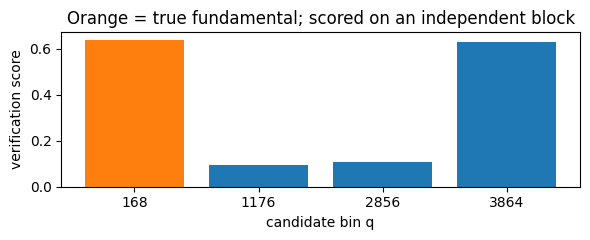

winner: q=168, correct: True
(a near-tie candidate at N - q0_true is the genuine -alpha0 mirror,
 scoring almost as high as +alpha0; both are real, and only one
 is the one sought here)


In [9]:
B_verify = 2000  # scaled down for this toy N; the real pipeline defaults to 4096
scores = {q: verify_candidate(x, lags, q / N, 0, B_verify) for q in combos}

fig, ax = plt.subplots(figsize=(6, 2.5))
qs = list(scores.keys())
vals = [scores[q] for q in qs]
colors = ["C1" if q == q0_true else "C0" for q in qs]
ax.bar([str(q) for q in qs], vals, color=colors)
ax.set_xlabel("candidate bin q")
ax.set_ylabel("verification score")
ax.set_title("Orange = true fundamental; scored on an independent block")
plt.tight_layout()
plt.show()

best_q = max(scores, key=scores.get)
print(f"winner: q={best_q}, correct: {best_q == q0_true}")
print("(a near-tie candidate at N - q0_true is the genuine -alpha0 mirror,")
print(" scoring almost as high as +alpha0; both are real, and only one")
print(" is the one sought here)")

## Stage 5: Harmonic-order resolution

Everything so far has assumed that the strongest cyclic feature in the
window is the fundamental. This holds for a plain rectangular- or
RRC-shaped signal, whose harmonic strength decays with order, but does not
hold in general. A short-code direct-sequence spread-spectrum (DSSS)
signal is the standard counterexample, since its comb can be nearly flat,
or even stronger at a harmonic than at the fundamental, so that the
location stage above locates the strongest feature confidently and
correctly, which is nonetheless the wrong answer.

A genuine DSSS-BPSK signal, built with a real length-31 spreading code,
illustrates this directly.

In [10]:
N2, M1_2, M2_2 = 8184, 88, 93   # a second coprime pair, sized for this signal
lags2 = [4, 8, 12, 16, 20, 24]

rng2 = np.random.default_rng(7)
x2, sym_period, sps_chip = make_dsss_signal(chip_rate=0.25, spreading_gain=31, N=N2, snr_db=10.0, rng=rng2)
q0_data = round(N2 / sym_period)
q0_chip = round(0.25 * N2)
print(f"true DATA rate bin: {q0_data}   true CHIP rate bin: {q0_chip}  (chip rate is {q0_chip/q0_data:.0f}x the data rate)")

ah_raw, q_raw, diag_raw = coprime_alpha0(x2, lags2, N2, M1_2, M2_2, resolve_order=False)
print(f"\nWITHOUT harmonic-order resolution: locates bin {q_raw}  ({q_raw/q0_data:.1f}x the true data rate, incorrect)")

ah_fixed, q_fixed, diag_fixed = coprime_alpha0(x2, lags2, N2, M1_2, M2_2, resolve_order=True)
print(f"WITH harmonic-order resolution:    locates bin {q_fixed}  (matches data rate: {q_fixed == q0_data})")

true DATA rate bin: 66   true CHIP rate bin: 2046  (chip rate is 31x the data rate)

WITHOUT harmonic-order resolution: locates bin 396  (6.0x the true data rate, incorrect)
WITH harmonic-order resolution:    locates bin 66  (matches data rate: True)


The correction (`resolve_harmonic_order`) tests every integer divisor $j$
of the located peak, asking whether $q_{\mathrm{pk}}/j$ is itself a real,
independently verifiable cyclic feature, checked against a noise floor
measured locally to that frequency rather than a global one (the
function's docstring discusses why a global floor and other approaches
were tried and rejected). The smallest divisor that passes is reported,
since every genuine harmonic is by definition an integer multiple of the
true fundamental.

### A closer look: why the comb confuses the location step

The comb is examined directly. Unlike the earlier QPSK signal, in which
the fundamental is clearly the strongest feature, a short-code DSSS
signal's harmonics remain comparably strong across many orders, and there
is no sharp decay to anchor a strongest-peak search on the true
fundamental.

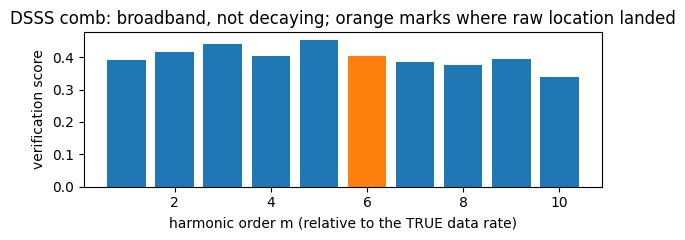

Every bar is comparably tall, which is what "broadband comb" means in practice.
The location stage isn't scanning this exact list; it only tests whichever bins
the two decimated branches happen to flag as strong peaks, and in this run that
happened to be m=6 (bin 396), not m=1.


In [11]:
B = 4096
harmonics_true = list(range(1, 11))
comb = [verify_candidate(x2, lags2, m * q0_data / N2, 0, B) for m in harmonics_true]

fig, ax = plt.subplots(figsize=(6, 2.5))
colors = ["C1" if m * q0_data == q_raw else "C0" for m in harmonics_true]
ax.bar(harmonics_true, comb, color=colors)
ax.set_xlabel("harmonic order m (relative to the TRUE data rate)")
ax.set_ylabel("verification score")
ax.set_title("DSSS comb: broadband, not decaying; orange marks where raw location landed")
plt.tight_layout()
plt.show()

print("Every bar is comparably tall, which is what \"broadband comb\" means in practice.")
print(f"The location stage isn't scanning this exact list; it only tests whichever bins")
print(f"the two decimated branches happen to flag as strong peaks, and in this run that")
print(f"happened to be m={q_raw // q0_data} (bin {q_raw}), not m=1.")

### Watching the divisor test run

The mechanism of `resolve_harmonic_order` is shown below. For the located
peak (`q_pk = 396`), every integer divisor $j$ up to $J=12$ is tested,
asking whether $q_{\mathrm{pk}}/j$ is itself a real cyclic feature, scored
against a noise floor measured locally to that candidate frequency. A
genuine harmonic of the true fundamental clears this test, while a
candidate that does not land on a real multiple of 66 does not.

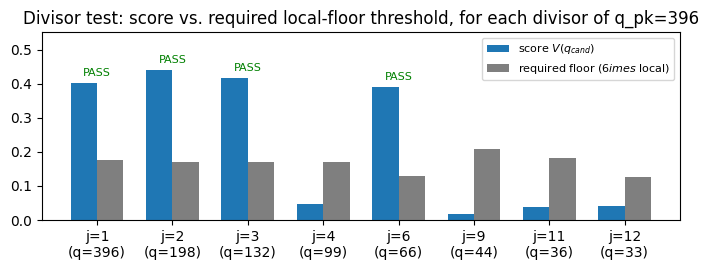

divisors tested: [1, 2, 3, 4, 6, 9, 11, 12]
candidates that pass: [396, 198, 132, 66]  (all are genuine multiples of the true fundamental, 66)
smallest passing candidate -> reported as the fundamental: 66


In [12]:
J = 12
rows = []
for j in range(1, J + 1):
    if q_raw % j != 0:
        continue
    q_cand = q_raw // j
    v = verify_candidate(x2, lags2, q_cand / N2, 0, B)
    floor = local_floor(x2, lags2, q_cand / N2, B)
    rows.append((j, q_cand, v, 6.0 * floor, v >= 6.0 * floor))

fig, ax = plt.subplots(figsize=(7, 2.8))
xpos = np.arange(len(rows))
width = 0.35
ax.bar(xpos - width/2, [r[2] for r in rows], width, label="score $V(q_{cand})$", color="C0")
ax.bar(xpos + width/2, [r[3] for r in rows], width, label="required floor ($6\times$ local)", color="C7")
ax.set_xticks(xpos)
ax.set_xticklabels([f"j={r[0]}\n(q={r[1]})" for r in rows])
ax.legend(fontsize=8)
ax.set_title("Divisor test: score vs. required local-floor threshold, for each divisor of q_pk=396")
for i, r in enumerate(rows):
    if r[4]:
        ax.annotate("PASS", (i, max(r[2], r[3]) + 0.02), ha="center", color="green", fontsize=8)
ax.set_ylim(0, max(max(r[2], r[3]) for r in rows) * 1.25)
plt.tight_layout()
plt.show()

passing = [r[1] for r in rows if r[4]]
print(f"divisors tested: {[r[0] for r in rows]}")
print(f"candidates that pass: {passing}  (all are genuine multiples of the true fundamental, {q0_data})")
print(f"smallest passing candidate -> reported as the fundamental: {min(passing)}")

## Stage 6: Profile readout

Once the fundamental bin $q_0$ is known exactly, every harmonic bin
$q_m = (m \cdot q_0) \bmod N$ is known exactly as well, so no further
search is required, only direct evaluation with the same
`verify_candidate` used above. This is the alpha-profile, the magnitude at
each harmonic, which is what a downstream task such as modulation
recognition or signal detection actually consumes.

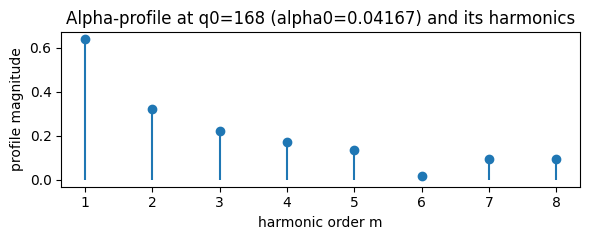

In [13]:
ah, q0_found, diag = coprime_alpha0(x, lags, N, M1, M2, B_verify=B_verify)

H = 8
harmonics = list(range(1, H + 1))
profile = [verify_candidate(x, lags, ((m * q0_found) % N) / N, 0, B_verify) for m in harmonics]

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.stem(harmonics, profile, basefmt=" ")
ax.set_xlabel("harmonic order m")
ax.set_ylabel("profile magnitude")
ax.set_title(f"Alpha-profile at q0={q0_found} (alpha0={q0_found/N:.5f}) and its harmonics")
plt.tight_layout()
plt.show()

## Putting it all together

The steps above, decimation folding, CRT recombination, mirror candidates,
verification, and harmonic-order resolution, are exactly what
`coprime_alpha0()` performs in one call. Both toy examples above are
confirmed to match end to end.

In [14]:
ah1, q1, diag1 = coprime_alpha0(x, lags, N, M1, M2, B_verify=2000)
print(f"toy example 1 (plain QPSK):  q={q1}, alpha_hat={ah1:.6f}, matches manual derivation: {q1 == q0_true}")

ah2, q2, diag2 = coprime_alpha0(x2, lags2, N2, M1_2, M2_2)
print(f"toy example 2 (DSSS):        q={q2}, alpha_hat={ah2:.6f}, matches manual derivation: {q2 == q0_data}")

toy example 1 (plain QPSK):  q=168, alpha_hat=0.041667, matches manual derivation: True
toy example 2 (DSSS):        q=66, alpha_hat=0.008065, matches manual derivation: True


## Where to go from here

`reproduce_paper.ipynb` runs the full experiment suite (recovery rates,
profile accuracy, cost scaling, the S3CA comparison, off-grid behavior) and
generates every figure and table as a PDF. The files `coprime.py`,
`fold_core.py`, and `twostage.py` contain the implementation itself, and
every function used above has a docstring explaining the reasoning behind
it, worth reading directly once the stages above are understood. The known
limitations of the method, namely the CRT's residue-error amplification,
the harmonic-order search depth bound, off-grid cycle frequencies, and the
two-signal spurious-lock case, are discussed in the paper and are worth
understanding before the method is applied to a new signal.